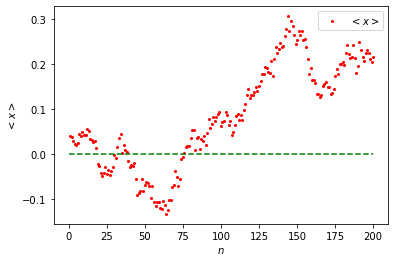

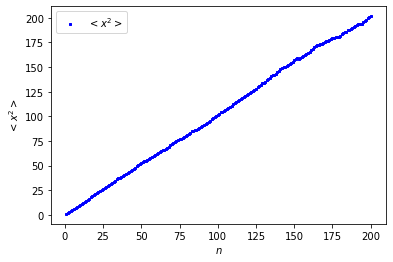

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def do_step(x):
    #this function choose a direction and move the walker one step to right or left
    r=np.random.choice(['L','R'])
    if r=='L':
        x=x-1
    else:
        x=x+1
    return(x)

def RW_dis(walkers,steps):
    #This function calculates the average distance from the origin after n steps in 1D_random walks
    #walkers: number of walkers(we need several walkers to calculate the average value)
    #steps: number of steps that each walker goes ultimately (the distance is calculated after 1,2,3,...,n steps)
    xav=[]
    x2av=[]
    W_place = np.zeros(walkers) #each element is the place of each walker
    for i in range (1,steps+1):
        for j in range (walkers):
            W_place[j] = do_step(W_place[j])
        xav.append(np.sum(W_place)/walkers)
        x2av.append(np.sum(W_place**2)/walkers)
    return(xav,x2av)


N = 3000 #Number of walkers
n = 200 #each walker goes n steps ultimately
xav,x2av=RW_dis(N,n)

    
step=[s+1 for s in range(n)]    
plt.plot(step,xav,'ro',markersize=2)
plt.hlines(0,0,n,'g',linestyles='--')
plt.legend(["$<x>$"])
plt.xlabel("$n$")
plt.ylabel("$<x>$")
plt.show() 
plt.plot(step,x2av,'bs',markersize=2)
plt.legend(["$<x^2>$"])
plt.xlabel("$n$")
plt.ylabel("$<x^2>$")
plt.show()       

The path was built at 52297'th attempts.


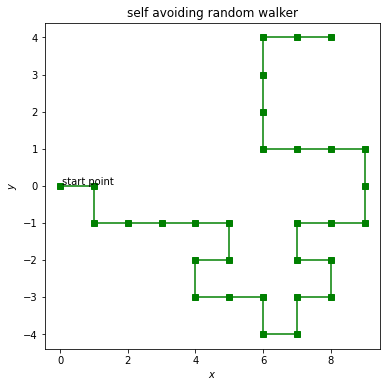

In [2]:
def do_step4(P):
    #this function choose a direction and move the walker one step from P=(x,y) in 2D
    x=P[0]
    y=P[1]
    r=np.random.choice(['N','S','E','W']) #random choice of direction
    if r=='N':
        y=y+1
    elif r=='S':
        y=y-1
    elif r=='E':
        x=x+1
    else:
        x=x-1
    return(x,y)

def SARW (start_point,step_number):
    # SARW: self avoiding random walks
    # this function makes a random 2D path with n step
    # start_point: the start point of walker
    # step_number: the number of steps
    i=0
    fault=0
    mypath=[] #the path points are saved here
    mypath.append(start_point)
    while i<step_number:
        nextpoint=do_step4(start_point)
        if nextpoint not in mypath:
            mypath.append(nextpoint)
            start_point=nextpoint
            i+=1
        else:
            fault+=1
            i=0
            del mypath[1:]
            start_point=mypath[0]
    return(mypath,fault)

start=(0,0) #the start point of walker
n=30 #the number of steps
SARW_path,fault=SARW(start,n)
           
#print(mypath)
print(f"The path was built at {fault+1}'th attempts.")
x, y = zip(*SARW_path)

plt.figure(figsize=(6, 6))
plt.plot(x,y,'-s', color='green')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("self avoiding random walker")
plt.annotate("start point",xy=np.array(SARW_path[0])+(0.04,0.04));
#plt.scatter(x, y, color='green', marker='s', s=40)

In [3]:
def SARW_dis(walkers,steps,start_point):
    #This function calculates the average distance from the origin after n steps in self avoiding random walks
    #walkers: number of walkers (we need several walkers to calculate the average value)
    #steps: number of steps that each walker goes ultimately (the distance is calculated after 1,2,3,...,n steps)
    rav=[]
    r2av=[]
    for i in range (1,steps+1):
        sumdis2=0
        sumdis=0
        for j in range (walkers):
            terminus=SARW (start_point,i)[0][-1]
            dis2=(terminus[0]-start_point[0])**2+(terminus[1]-start_point[1])**2
            dis=np.sqrt(dis2)
            sumdis2+=dis2
            sumdis+=dis
        rav.append(sumdis/walkers)
        r2av.append(sumdis2/walkers)
    return(rav,r2av)


N = 500 #Number of walkers
n = 15 #each walker goes n steps ultimately
rav,r2av=SARW_dis(N,n,(0,0))

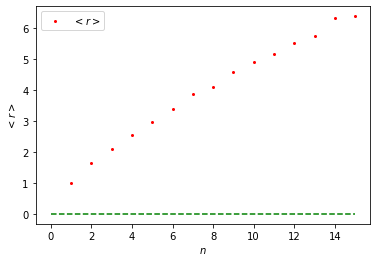

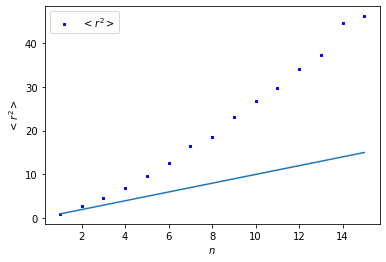

In [4]:
step=[s+1 for s in range(n)]    
plt.plot(step,rav,'ro',markersize=2)
plt.hlines(0,0,n,'g',linestyles='--')
plt.legend(["$<r>$"])
plt.xlabel("$n$")
plt.ylabel("$<r>$")
plt.show() 
plt.plot(step,r2av,'bs',markersize=2)
u=[step[0],step[-1]]
plt.plot(u,u)
plt.legend(["$<r^2>$"])
plt.xlabel("$n$")
plt.ylabel("$<r^2>$")
plt.show()       